In [142]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Chart of values: This part of the notebook is for troubleshooting and graphical analysis.

In [143]:
raw_fuel_data=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\projects\data\yavel\bxz919_1424_0326.csv',sep=',',encoding='latin1')
raw_fuel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7313 entries, 0 to 7312
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  7313 non-null   str  
 1   Message  7313 non-null   str  
 2   Status   7313 non-null   str  
dtypes: str(3)
memory usage: 171.5 KB


In [144]:
e0x=raw_fuel_data[raw_fuel_data['Status'].str.contains('3E0')]
row_number=e0x.shape[0]
#e0x.to_csv('/home/jlhb1984/py-projects/data/veepo/wcr728_.csv')

In [145]:
fs01_dec_value=[]
fs02_dec_value=[]
last_index_fs01=[]
last_index_fs02=[]
date_fs01_dec_value=[]
date_fs02_dec_value=[]
sequence_fs01=[]
sequence_fs02=[]
values_dates_fs01=pd.DataFrame()
values_dates_fs02=pd.DataFrame()

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E01')    
    if len(e0x_aux)>0:
        fs01=(e0x_aux[aux:aux+18])
        if len(fs01)>17:
            msb=fs01[10:12]
            lsb=fs01[8:10]
            measure=msb+lsb
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,0])
            sequence_fs01.append(e0x.iloc[i,2][24:28])                  
            #last_index_fs01=i
            msb=fs01[28:30]
            lsb=fs01[26:28]
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,0])
            sequence_fs01.append(e0x.iloc[i,2][24:28])                  
            msb=fs01[46:48]
            lsb=fs01[44:46]
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,0])
            sequence_fs01.append(e0x.iloc[i,2][24:28])                  
            msb=fs01[46:48]
            lsb=fs01[44:46]
            fs01_dec_value.append(int(measure,16))
            date_fs01_dec_value.append(e0x.iloc[i,0])
            sequence_fs01.append(e0x.iloc[i,2][24:28])                  
            msb=fs01[64:66]
            lsb=fs01[62:64]
            
            
print(i, raw_fuel_data.iloc[i,0] )

for i in range(0,row_number):
    e0x_aux=e0x.iloc[i,2]
    aux=e0x_aux.find('3E02')
    if len(e0x_aux)>0:
        fs02=e0x_aux[aux:aux+18]
        if len(fs02)>17:
            msb=fs02[10:12]
            lsb=fs02[8:10]
            measure=msb+lsb
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,0])
            sequence_fs02.append(e0x.iloc[i,2][24:28])        
            msb=fs02[28:30]
            lsb=fs02[26:28]
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,0]) 
            sequence_fs02.append(e0x.iloc[i,2][24:28])
            msb=fs02[46:48]
            lsb=fs02[44:46]
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,0])
            sequence_fs02.append(e0x.iloc[i,2][24:28])
            msb=fs02[46:48]
            lsb=fs02[44:46]
            fs02_dec_value.append(int(measure,16))
            date_fs02_dec_value.append(e0x.iloc[i,0])
            sequence_fs02.append(e0x.iloc[i,2][24:28])
            msb=fs02[64:66]
            lsb=fs02[62:64]                 
            
        #print(fs01_cad)   

fs01_count=len(fs01_dec_value)
fs02_count=len(fs02_dec_value)
values_dates_fs01['Value fs01']=fs01_dec_value
values_dates_fs01['Dates fs01']=date_fs01_dec_value
values_dates_fs02['Value fs02']=fs02_dec_value
values_dates_fs02['Dates fs02']=date_fs02_dec_value
values_dates_fs01['Sequence fs01']=sequence_fs01

#print('El Ncode en decimal es:')
print(fs02_dec_value,fs02_count)
print("Last fuel report fs01: ",e0x.iloc[last_index_fs01,0],"Last fuel report fs02: ",e0x.iloc[last_index_fs02,0])            


2975 2026-03-18 12:34:25.153
[6407, 6407, 6407, 6407, 40386, 40386, 40386, 40386, 1281, 1281, 1281, 1281, 2327, 2327, 2327, 2327] 16
Last fuel report fs01:  Series([], Name: Created, dtype: str) Last fuel report fs02:  Series([], Name: Created, dtype: str)


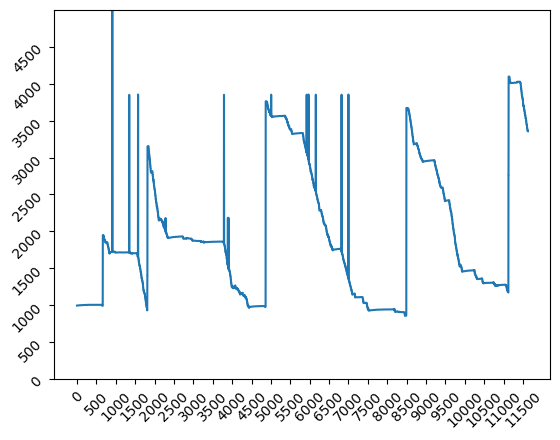

In [146]:
fs01_x_values=[]
fs02_x_values=[]

for i in range(0,fs01_count):
    fs01_x_values.append(i)
    
for i in range(0,fs02_count):
    fs02_x_values.append(i)
    
plt.xticks(range(0,12000,500),rotation=45)
plt.yticks(range(0,5000,500),rotation=45)
plt.ylim(0,5000)
plt.plot(fs01_x_values,fs01_dec_value)
#plt.plot(fs02_x_values,fs02_dec_value)

In [147]:
for i in range(0,values_dates_fs01.shape[0]):
    if values_dates_fs01.iloc[i,0]>=24000:
        print(values_dates_fs01.iloc[i,0],' -> ',values_dates_fs01.iloc[i,1])

24001  ->  2026-03-14 20:13:18.645
24001  ->  2026-03-14 20:13:18.645
24001  ->  2026-03-14 20:13:18.645
24001  ->  2026-03-14 20:13:18.645


In [148]:
values_dates_fs01.to_csv(r'C:\Users\Jose.Hurtado\Documents\projects\data\yavel\fs01.csv')

In [149]:
#Rising 2026-03-14 14:47
value_to_look='2026-03-14 14:4'
frs=values_dates_fs01[values_dates_fs01['Dates fs01'].str.contains(value_to_look)]
print(frs)

     Value fs01               Dates fs01 Sequence fs01
660         995  2026-03-14 14:42:32.652          3D59
661         995  2026-03-14 14:42:32.652          3D59
662         995  2026-03-14 14:42:32.652          3D59
663         995  2026-03-14 14:42:32.652          3D59
664        1950  2026-03-14 14:47:52.661          3D5C
665        1950  2026-03-14 14:47:52.661          3D5C
666        1950  2026-03-14 14:47:52.661          3D5C
667        1950  2026-03-14 14:47:52.661          3D5C


In [150]:
#Rising 2026-03-15 16:08
value_to_look='2026-03-15 16:0'
frs=values_dates_fs01[values_dates_fs01['Dates fs01'].str.contains(value_to_look)]
print(frs)

      Value fs01               Dates fs01 Sequence fs01
1808         932  2026-03-15 16:02:19.747          3FDE
1809         932  2026-03-15 16:02:19.747          3FDE
1810         932  2026-03-15 16:02:19.747          3FDE
1811         932  2026-03-15 16:02:19.747          3FDE
1812        1402  2026-03-15 16:08:05.699          3FDF
1813        1402  2026-03-15 16:08:05.699          3FDF
1814        1402  2026-03-15 16:08:05.699          3FDF
1815        1402  2026-03-15 16:08:05.699          3FDF


In [151]:
#Rising 2026-03-15 16:13
value_to_look='2026-03-15 16:1'
frs=values_dates_fs01[values_dates_fs01['Dates fs01'].str.contains(value_to_look)]
print(frs)

value_to_look='2026-03-15 16:2'
frs=values_dates_fs01[values_dates_fs01['Dates fs01'].str.contains(value_to_look)]
print(frs)

      Value fs01               Dates fs01 Sequence fs01
1816        3149  2026-03-15 16:13:25.821          3FE4
1817        3149  2026-03-15 16:13:25.821          3FE4
1818        3149  2026-03-15 16:13:25.821          3FE4
1819        3149  2026-03-15 16:13:25.821          3FE4
1820        3150  2026-03-15 16:18:45.704          3FE6
1821        3150  2026-03-15 16:18:45.704          3FE6
1822        3150  2026-03-15 16:18:45.704          3FE6
1823        3150  2026-03-15 16:18:45.704          3FE6
      Value fs01               Dates fs01 Sequence fs01
1824        3146  2026-03-15 16:24:05.755          3FEA
1825        3146  2026-03-15 16:24:05.755          3FEA
1826        3146  2026-03-15 16:24:05.755          3FEA
1827        3146  2026-03-15 16:24:05.755          3FEA
1828        3146  2026-03-15 16:28:59.740          3FEC
1829        3146  2026-03-15 16:28:59.740          3FEC
1830        3146  2026-03-15 16:28:59.740          3FEC
1831        3146  2026-03-15 16:28:59.740       

In [152]:
#Rising 2026-03-18 11:20
value_to_look='2026-03-18 11:1'
frs=values_dates_fs01[values_dates_fs01['Dates fs01'].str.contains(value_to_look)]
print(frs)

value_to_look='2026-03-18 11:2'
frs=values_dates_fs01[values_dates_fs01['Dates fs01'].str.contains(value_to_look)]
print(frs)

value_to_look='2026-03-18 11:3'
frs=values_dates_fs01[values_dates_fs01['Dates fs01'].str.contains(value_to_look)]
print(frs)

      Value fs01               Dates fs01 Sequence fs01
4860         982  2026-03-18 11:15:09.055          47EC
4861         982  2026-03-18 11:15:09.055          47EC
4862         982  2026-03-18 11:15:09.055          47EC
4863         982  2026-03-18 11:15:09.055          47EC
      Value fs01               Dates fs01 Sequence fs01
4864        3761  2026-03-18 11:20:29.118          47F2
4865        3761  2026-03-18 11:20:29.118          47F2
4866        3761  2026-03-18 11:20:29.118          47F2
4867        3761  2026-03-18 11:20:29.118          47F2
4868        3761  2026-03-18 11:25:49.258          47F5
4869        3761  2026-03-18 11:25:49.258          47F5
4870        3761  2026-03-18 11:25:49.258          47F5
4871        3761  2026-03-18 11:25:49.258          47F5
      Value fs01               Dates fs01 Sequence fs01
4872        3761  2026-03-18 11:31:02.921          47F6
4873        3761  2026-03-18 11:31:02.921          47F6
4874        3761  2026-03-18 11:31:02.921       

In [153]:
#Rising 2026-03-21 13:54
value_to_look='2026-03-21 18:4'
frs=values_dates_fs01[values_dates_fs01['Dates fs01'].str.contains(value_to_look)]
print(frs)

value_to_look='2026-03-21 18:5'
frs=values_dates_fs01[values_dates_fs01['Dates fs01'].str.contains(value_to_look)]
print(frs)

      Value fs01               Dates fs01 Sequence fs01
8484         861  2026-03-21 18:43:38.877          50AA
8485         861  2026-03-21 18:43:38.877          50AA
8486         861  2026-03-21 18:43:38.877          50AA
8487         861  2026-03-21 18:43:38.877          50AA
8488         864  2026-03-21 18:48:58.307          50AE
8489         864  2026-03-21 18:48:58.307          50AE
8490         864  2026-03-21 18:48:58.307          50AE
8491         864  2026-03-21 18:48:58.307          50AE
      Value fs01               Dates fs01 Sequence fs01
8492        3666  2026-03-21 18:54:19.382          50B7
8493        3666  2026-03-21 18:54:19.382          50B7
8494        3666  2026-03-21 18:54:19.382          50B7
8495        3666  2026-03-21 18:54:19.382          50B7
8496        3670  2026-03-21 18:59:39.040          50BA
8497        3670  2026-03-21 18:59:39.040          50BA
8498        3670  2026-03-21 18:59:39.040          50BA
8499        3670  2026-03-21 18:59:39.040       

In [154]:
#Rising 2026-03-24 05:07  
value_to_look='2026-03-24 05:0'
frs=values_dates_fs01[values_dates_fs01['Dates fs01'].str.contains(value_to_look)]
print(frs)

       Value fs01               Dates fs01 Sequence fs01
11120        1174  2026-03-24 05:02:11.823          578C
11121        1174  2026-03-24 05:02:11.823          578C
11122        1174  2026-03-24 05:02:11.823          578C
11123        1174  2026-03-24 05:02:11.823          578C
11124        2761  2026-03-24 05:07:31.855          578D
11125        2761  2026-03-24 05:07:31.855          578D
11126        2761  2026-03-24 05:07:31.855          578D
11127        2761  2026-03-24 05:07:31.855          578D


In [155]:
#Rising 2026-03-24 05:13
value_to_look='2026-03-24 05:1'
frs=values_dates_fs01[values_dates_fs01['Dates fs01'].str.contains(value_to_look)]
print(frs)

       Value fs01               Dates fs01 Sequence fs01
11128        4095  2026-03-24 05:12:51.904          5790
11129        4095  2026-03-24 05:12:51.904          5790
11130        4095  2026-03-24 05:12:51.904          5790
11131        4095  2026-03-24 05:12:51.904          5790
11132        4095  2026-03-24 05:18:11.919          5794
11133        4095  2026-03-24 05:18:11.919          5794
11134        4095  2026-03-24 05:18:11.919          5794
11135        4095  2026-03-24 05:18:11.919          5794


In [156]:
#Rising based on invoice:
value_to_look='2026-03-17 22:4'
frs=values_dates_fs01[values_dates_fs01['Dates fs01'].str.contains(value_to_look)]
print(frs)

value_to_look='2026-03-17 22:5'
frs=values_dates_fs01[values_dates_fs01['Dates fs01'].str.contains(value_to_look)]
print(frs)

value_to_look='2026-03-17 23:0'
frs=values_dates_fs01[values_dates_fs01['Dates fs01'].str.contains(value_to_look)]
print(frs)

value_to_look='2026-03-17 23:1'
frs=values_dates_fs01[values_dates_fs01['Dates fs01'].str.contains(value_to_look)]
print(frs)

      Value fs01               Dates fs01 Sequence fs01
4296        1139  2026-03-17 22:42:38.517          46DC
4297        1139  2026-03-17 22:42:38.517          46DC
4298        1139  2026-03-17 22:42:38.517          46DC
4299        1139  2026-03-17 22:42:38.517          46DC
4300        1128  2026-03-17 22:48:00.042          46E3
4301        1128  2026-03-17 22:48:00.042          46E3
4302        1128  2026-03-17 22:48:00.042          46E3
4303        1128  2026-03-17 22:48:00.042          46E3
      Value fs01               Dates fs01 Sequence fs01
4304        1127  2026-03-17 22:53:18.620          46E7
4305        1127  2026-03-17 22:53:18.620          46E7
4306        1127  2026-03-17 22:53:18.620          46E7
4307        1127  2026-03-17 22:53:18.620          46E7
4308        1125  2026-03-17 22:58:58.909          46EA
4309        1125  2026-03-17 22:58:58.909          46EA
4310        1125  2026-03-17 22:58:58.909          46EA
4311        1125  2026-03-17 22:58:58.909       

Sequences:

In [159]:
e0x_aux=raw_fuel_data
e0x_sequences=[]
e0x_sequences_dec=[]

for i in range(0,e0x_aux.shape[0]):
    e0x_sequences.append(e0x_aux.iloc[i,2][24:28])
    e0x_sequences_dec.append(int(e0x_aux.iloc[i,2][24:28],16))
#e0x_sequences_dec

data=np.array(e0x_sequences)
unique, counts = np.unique(data, return_counts=True)

duplicates = unique[counts > 1]
print("Duplicated values:", duplicates)

e0x_aux['Sequences']=e0x_sequences_dec

Duplicated values: ['3EFC' '4062' '4063' '40D8' '40F8' '4125' '4160' '4162' '41AF' '421A'
 '421D' '422F' '4235' '4259' '453B' '4541' '4556' '459A' '45A1' '45B2'
 '460F' '4636' '4653' '46DD' '4742' '4934' '4955' '4979' '497B' '4983'
 '4AB0' '4B5C' '4BE9' '4D79' '4E0D' '4E3D' '4EDC' '4F0A' '4F1D' '4F41'
 '4FA1' '4FA7' '5096' '5098' '51F8' '5207' '5215' '5283' '52DB' '5317'
 '536B' '53AC' '53EA' '550F' '5512' '5581' '559B' '55B4' '576E' '57C0'
 '5830' '5845' '58B9' '58D9']


In [160]:
value_to_look='2026-03-17 22:4'
frs=e0x_aux[e0x_aux['Created'].str.contains(value_to_look)]
print(frs[['Created','Sequences']])

value_to_look='2026-03-17 22:5'
frs=e0x_aux[e0x_aux['Created'].str.contains(value_to_look)]
print(frs[['Created','Sequences']])

value_to_look='2026-03-17 23:0'
frs=e0x_aux[e0x_aux['Created'].str.contains(value_to_look)]
print(frs[['Created','Sequences']])

value_to_look='2026-03-17 23:1'
frs=e0x_aux[e0x_aux['Created'].str.contains(value_to_look)]
print(frs[['Created','Sequences']])

                      Created  Sequences
2656  2026-03-17 22:41:27.175      18139
2657  2026-03-17 22:42:38.517      18140
2658  2026-03-17 22:42:44.537      18141
2659  2026-03-17 22:43:00.172      18141
2660  2026-03-17 22:44:03.126      18142
2661  2026-03-17 22:45:25.220      18143
2662  2026-03-17 22:46:18.260      18144
2663  2026-03-17 22:46:58.202      18145
2664  2026-03-17 22:47:49.142      18146
2665  2026-03-17 22:48:00.042      18147
2666  2026-03-17 22:48:29.190      18148
                      Created  Sequences
2667  2026-03-17 22:50:04.265      18149
2668  2026-03-17 22:52:44.654      18150
2669  2026-03-17 22:53:18.620      18151
2670  2026-03-17 22:53:25.832      18152
2671  2026-03-17 22:53:39.117      18153
2672  2026-03-17 22:58:58.909      18154
                      Created  Sequences
2673  2026-03-17 23:01:15.575      18155
2674  2026-03-17 23:04:15.303      18156
2675  2026-03-17 23:04:18.189      18157
2676  2026-03-17 23:04:29.318      18158
2677  2026-03-17